# Tarea

Individualmente van a elegir una pelicula o libro , y van a crear un agente que devuelva una estructura Json las incoherencias relevantes de cada una de ellas, tiene que aplicar todo lo visto hasta acá, plazo máximo para acabar será hasta una hora antes de la clase!

Los roles de sus Agentes:

- Un agente que piense como un sacerdote
- Un critico de cine
- Un critico del critico
- Un agente que juzgue quien tiene la razón

# Pelicula: El Secreto de sus Ojos 

Cuatro agentes analizan las incoherencias de **El Secreto de sus Ojos (2009)** de Juan José Campanella, con Guillermo Francella como Pablo Sandoval.

Sacerdote  →  Crítico  →  Crítico del crítico  →  Juez (JSON final)


| Agente | Rol |
|--------|-----|
| Sacerdote |  análisis moral y teológico |
| Crítico de cine | análisis narrativo y jurídico |
| Crítico del crítico  |  detecta sesgos |
| Juez | emite veredicto en JSON estructurado |

In [12]:
# instalo dependencies necesarias para el proyecto
%pip install -q langchain-classic langchain-openai langchain-core langgraph python-dotenv


Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser, PydanticOutputParser
from langchain_core.exceptions import OutputParserException
from langchain_classic.output_parsers import DatetimeOutputParser
from langchain_classic.output_parsers import BooleanOutputParser
from langchain_classic.output_parsers import OutputFixingParser
import logging
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langchain_core.prompts import PromptTemplate, FewShotPromptTemplate
from IPython.display import display, Markdown
from typing import List, Optional

from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.prompts import (
    ChatPromptTemplate,
    FewShotChatMessagePromptTemplate,
)
from pydantic import BaseModel, Field

/Users/mauroorias/Documents/henry/a2a/secreto_de_sus_ojos/.venv/lib/python3.14/site-packages/langchain_core/_api/deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [13]:
# variables de entorno
from dotenv import load_dotenv
import os

load_dotenv()

OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY")
print("OPENAI_API_KEY cargada correctamente.")

OPENAI_API_KEY cargada correctamente.


In [14]:
# Diseñando un logger sencillito
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(name)s - %(levelname)s - %(message)s",
    force=True,
)
logger = logging.getLogger("SecretoOjosA2A")


def llm():
    """Cada agente tiene su propia instancia de LLM."""
    return ChatOpenAI(
        model="gpt-4o-mini",
        openai_api_key=OPENAI_API_KEY,
        max_tokens=2000,
    )

logger.info("Setup completo")
print("✅ Setup OK")

2026-03-08 19:38:27,989 - SecretoOjosA2A - INFO - Setup completo


✅ Setup OK


In [15]:
logger.info("Testing ApiCall")
print(
    llm().invoke(
        "¿Cuál es la incoherencia más grave en El Secreto de sus Ojos (2009)?"
    )
)

2026-03-08 19:38:32,757 - SecretoOjosA2A - INFO - Testing ApiCall
2026-03-08 19:38:39,382 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


content='"El secreto de sus ojos", tanto en la novela de Eduardo Sacheri como en su adaptación cinematográfica, es una obra muy valorada, pero como en cualquier narrativa, puede haber puntos que generen debate. Una incoherencia que algunos críticos y espectadores han señalado tiene que ver con la forma en que se resuelven ciertos conflictos de la trama y los giros en la narrativa. \n\nPor ejemplo, algunos pueden argumentar que la manera en que el protagonista, Benjamín Esposito, se obsesiona con el caso de asesinato de Liliana Colotto es un tanto inverosímil, especialmente considerando la cantidad de años que pasan desde el crimen hasta el desenlace, y cómo eso afecta tanto su vida personal como su carrera. Además, hay quienes pueden notar inconsistencias en la caracterización de algunos personajes o en sus decisiones a lo largo de la historia, que pueden parecer forzadas o poco desarrolladas en ciertos momentos.\n\nSin embargo, es importante tener en cuenta que estas "incoherencias" s

In [ ]:
# Este es un ejemplo de cómo podríamos estructurar la conversación con el modelo para analizar la película. Cada mensaje tiene un rol específico 
# (SystemMessage para contextualizar el rol del modelo, 
# HumanMessage para las preguntas del usuario,
#  y AIMessage para las respuestas del modelo). El modelo procesará esta secuencia de mensajes y generará una respuesta basada en el contexto proporcionado.
# Esto es util para guiar al modelo a adoptar un enfoque crítico y experto en su análisis, asegurando que sus respuestas sean relevantes y fundamentadas en el conocimiento del cine argentino y la narrativa de la película.
messages = [
    SystemMessage(
        "Eres un experto en cine argentino y análisis narrativo. "
        "Respondes en español, con rigor crítico y precisión histórica."
    ), # Contextualización del rol del modelo - Rol de experto en cine argentino
    HumanMessage(
        "¿Por qué Benjamín Esposito no actuó antes para salvar a Liliana Coloto "
        "si tenía pruebas suficientes para identificar a Isidoro Gómez?"
    ), # Pregunta específica sobre la trama de la película
    AIMessage(
        "La inacción de Esposito no es un error narrativo, sino el núcleo dramático de la película. "
        "Las pruebas que tenía eran circunstanciales: fotografías de un partido de fútbol y "
        "la obsesión documentada de Gómez por Liliana. No eran suficientes para una condena formal. "
        "Además, Esposito operaba dentro de un sistema judicial corrupto en la Argentina de los '70, "
        "donde el poder político podía liberar a cualquier detenido. "
        "Su parálisis refleja tanto la impotencia institucional como su cobardía personal, "
        "que Campanella equipara deliberadamente con su incapacidad para declarar su amor a Irene."
    ), # Respuesta detallada que justifica la inacción de Esposito, relacionándola con el contexto histórico y los temas de la película
    HumanMessage(
        "¿Cómo justifica la película que Morales haya podido mantener a Gómez encerrado durante 25 años sin que nadie lo descubriera?"
    ), # Segunda pregunta que aborda otro punto de la trama
]

response = llm().invoke(messages)
print(response.content)

2026-03-08 19:40:33,809 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


La película "El secreto de sus ojos" sugiere que la situación de impunidad y corrupción del sistema judicial argentino de la época permite que Morales mantenga a Isidoro Gómez encerrado sin que se descubra. Este contexto de falta de justicia y complicidad entre autoridades se muestra como un entorno donde las acciones de Morales, aunque moralmente cuestionables, se vuelven posibles.

Además, la narrativa sugiere que el poder y la violencia pueden encerrar a una persona en un limbo legal. Morales, un ex policía, utiliza su propio conocimiento del sistema y su influencia para llevar a cabo su venganza sin ser atrapado. El ambiente de miedo y rechazo a confrontar a las autoridades, característico de la época, también refuerza esta idea, ya que la sociedad se muestra apática o temerosa de intervenir en cuestiones tan profundas y peligrosas como el asesinato y la justicia personal. En definitiva, la dualidad entre la justicia formal y la justicia personal crea un espacio donde la complicida

---
## 1. FewShot — contexto sobre la película

In [17]:
from langchain_core.prompts import PromptTemplate, FewShotPromptTemplate
from IPython.display import display, Markdown

# Definimos un formato de prompt para cada ejemplo, con una pregunta, un razonamiento y una respuesta.
example_prompt = PromptTemplate(
    template="Question: {input}\nThought: {thought}\nResponse: {output}"
)

# Ejemplos para Few-Shot Prompting, cada uno con una pregunta, un razonamiento detallado y una respuesta concreta.
examples = [
    {
        "input": "¿Por qué Isidoro Gómez no fue condenado la primera vez que fue detenido?",
        "thought": "Gómez fue detenido por Esposito pero liberado rápidamente gracias a Romano, quien lo incorporó como informante de la Triple A. El sistema judicial estaba cooptado por el poder paraestatal durante el gobierno de Isabel Perón.",
        "output": "Romano lo liberó usándolo como informante de la Triple A, aprovechando la corrupción judicial de la época.",
    },
    {
        "input": "¿Cómo identificó Esposito a Gómez como el asesino de Liliana Coloto?",
        "thought": "Esposito revisó cientos de fotos de los álbumes de fútbol de Liliana y descubrió que Gómez aparecía repetidamente mirándola con obsesión. La mirada fue la clave: Esposito concluye que un hombre solo mira así a la mujer que ama.",
        "output": "A través de fotos de partidos de fútbol donde Gómez miraba obsesivamente a Liliana. La mirada lo delató.",
    },
    {
        "input": "¿Qué representa el partido de fútbol de Racing Club en la trama?",
        "thought": "Racing Club es la pasión irrefrenable de Gómez, su único punto ciego. Esposito usa ese fanatismo para tenderle una trampa en el estadio, sabiendo que Gómez no puede resistir ver a su equipo. El fútbol funciona como metáfora de las obsesiones que nos dominan.",
        "output": "Es la trampa que usa Esposito: la pasión de Gómez por Racing era su único punto ciego, y lo llevó a ser capturado en el estadio.",
    },
    {
        "input": "¿Qué papel juega Pablo Sandoval en la resolución del caso?",
        "thought": "Sandoval es el genio intuitivo y autodestructivo que tiene la idea clave: buscar a Gómez por su pasión por Racing. Su sacrificio final, cuando muere en lugar de Esposito, es el acto que obliga a Benjamín a exiliarse y abandonar el caso por décadas.",
        "output": "Aporta la intuición decisiva del fútbol y su muerte fuerza el exilio de Esposito, congelando el caso 25 años.",
    },
    {
        "input": "¿Por qué Morales decidió encarcelar a Gómez en su propia casa en lugar de matarlo?",
        "thought": "Morales quería una condena proporcional al crimen: que Gómez viviera el mismo vacío eterno que él sufrió al perder a Liliana. La muerte sería un final rápido; el encierro perpetuo sin esperanza era la verdadera venganza. También replica la estructura de la película: la condena más cruel es vivir sin la persona amada.",
        "output": "Porque la muerte era demasiado rápida. Quería que Gómez sufriera el mismo vacío perpetuo que él vivió sin Liliana.",
    },
]

# Probamos el ejemplo para asegurarnos de que el formato es correcto
print(example_prompt.invoke(examples[0]).to_string())

# Ahora armamos el Few-Shot Prompt Template con los ejemplos y el formato definido
prompt_template = FewShotPromptTemplate(
    examples=examples,
    example_prompt=example_prompt,
    suffix="Question: {input}",
    input_variables=["input"],
)

# Probamos el Few-Shot Prompt Template con una nueva pregunta para ver cómo se formatea el prompt completo
response = llm().invoke(
    prompt_template.invoke(
        {"input": "¿Qué paralelo traza Campanella entre la cobardía de Esposito con Irene y su inacción en el caso Coloto?"}
    )
)
# Finalmente, mostramos la respuesta del modelo en formato Markdown para una mejor legibilidad.
display(Markdown(response.content))

Question: ¿Por qué Isidoro Gómez no fue condenado la primera vez que fue detenido?
Thought: Gómez fue detenido por Esposito pero liberado rápidamente gracias a Romano, quien lo incorporó como informante de la Triple A. El sistema judicial estaba cooptado por el poder paraestatal durante el gobierno de Isabel Perón.
Response: Romano lo liberó usándolo como informante de la Triple A, aprovechando la corrupción judicial de la época.


2026-03-08 19:42:21,911 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Thought: Campanella sugiere que la cobardía de Esposito en la vida personal, al no confrontar su amor por Irene, se refleja en su inacción durante la investigación del caso Coloto. Ambas situaciones muestran su miedo a tomar decisiones valientes y a asumir responsabilidades, lo que lleva a consecuencias trágicas tanto en su vida amorosa como en la búsqueda de justicia.

Response: Campanella establece un paralelo entre la cobardía de Esposito en su relación con Irene, al no enfrentar sus sentimientos, y su falta de acción en el caso Coloto, evidenciando cómo su miedo a comprometerse y actuar tiene repercusiones destructivas en ambos ámbitos.

### Creando un chatbot con estructura

In [ ]:
# --- Schemas Pydantic: estructura del JSON que devuelven los 4 agentes ---
# esto sirve para definir la estructura de los datos que esperamos recibir de cada agente. 
# Al usar Pydantic, podemos validar que las respuestas del modelo se ajusten a esta estructura, lo que nos ayuda a mantener un formato consistente y facilita el análisis posterior. 
# Cada clase representa un aspecto diferente del análisis: 
# Incoherencia para las inconsistencias detectadas, 
# AnalisisSacerdote para la perspectiva moral,
#  AnalisisCritico para el análisis narrativo y jurídico, 
# AnalisisMetacritico para detectar sesgos en el crítico, y VeredictoChatbot para consolidar todo el análisis en un veredicto final.

class Incoherencia(BaseModel): # Representa una incoherencia detectada por cualquiera de los agentes
    titulo: str = Field(description="Nombre corto de la incoherencia")
    descripcion: str = Field(description="Explicación detallada")
    gravedad: int = Field(description="Gravedad narrativa del 1 al 10")

class AnalisisSacerdote(BaseModel): # 
    """Agente 1 — Padre Ignacio: perspectiva moral y teológica."""
    perspectiva_moral: str = Field(description="Lectura ética del dilema central")
    incoherencias: List[Incoherencia] = Field(description="Incoherencias desde la moral católica")
    veredicto_moral: str = Field(description="'absolución' | 'pecado venial' | 'pecado mortal'")

class AnalisisCritico(BaseModel):
    """Agente 2 — Crítico de cine: análisis narrativo y jurídico."""
    analisis_narrativo: str = Field(description="Coherencia de la trama como obra cinematográfica")
    incoherencias: List[Incoherencia] = Field(description="Incoherencias narrativas o jurídicas")
    puntuacion: float = Field(description="Puntuación de coherencia del 1 al 10")

class AnalisisMetacritico(BaseModel):
    """Agente 3 — Meta-crítico: detecta sesgos en el Crítico."""
    sesgos_detectados: List[str] = Field(description="Lista de sesgos o puntos ciegos del Crítico")
    critica_al_critico: str = Field(description="Argumento contra el análisis del Crítico")
    critica_es_valida: bool = Field(description="¿La crítica del Crítico resiste el escrutinio?")

class VeredictoChatbot(BaseModel):
    """Agente 4 — Juez: consolida todo en el JSON final."""
    pelicula: str = Field(description="Título de la película analizada")
    incoherencias_confirmadas: List[Incoherencia] = Field(
        description="Solo las incoherencias que sobrevivieron al meta-análisis"
    )
    analisis_sacerdote: AnalisisSacerdote
    analisis_critico: AnalisisCritico
    analisis_metacritico: AnalisisMetacritico
    quien_tiene_razon: str = Field(description="'sacerdote' | 'critico' | 'ambos' | 'ninguno'") # Quién tiene la razón según el Juez. Aca se espera un análisis complejo que puede concluir que ambos tienen puntos válidos o que ninguno tiene la razón absoluta.
    veredicto_final: str = Field(description="Conclusión del Juez en 2-3 oraciones") # Acá el Juez debe sintetizar todo el análisis previo para dar una conclusión clara sobre la coherencia de la película, destacando las incoherencias más graves y explicando su impacto en la narrativa global.

In [ ]:

# --- Chatbot con with_structured_output y memoria de conversación ---

structured_llm = llm().with_structured_output(VeredictoChatbot)

messages = [
    SystemMessage(
        "Eres un juez cinematográfico que consolida los análisis de 4 agentes: "
        "un sacerdote, un crítico de cine, un meta-crítico y el propio juez. "
        "Respondes siempre con el JSON estructurado solicitado."
    ),
    HumanMessage("Analiza las incoherencias de 'El Secreto de sus Ojos (2009)' desde los 4 roles.")
]

resultado = structured_llm.invoke(messages)
print(resultado.model_dump_json(indent=2))


---
## 2. Agentes con Tools — Los 4 roles de la Tarea

In [20]:
from langchain_core.tools import tool
from langchain_core.messages import ToolMessage

# ─────────────────────────────────────────────
# TOOLS — base de conocimiento de la película
# ─────────────────────────────────────────────

@tool
def consultar_personaje(nombre: str) -> str:
    """Consulta ficha de un personaje de El Secreto de sus Ojos.
    Úsala cuando necesites datos concretos sobre un personaje antes de emitir tu análisis."""
    personajes = {
        "esposito": "Benjamín Esposito. Oficial judicial retirado que investiga el crimen 25 años después. "
                    "Su inacción ante Gómez espeja su cobardía para declarar su amor a Irene.",
        "irene": "Irene Hastings. Jefa de Esposito. Su relación con Benjamín queda suspendida por décadas "
                 "en una tensión no resuelta que la película equipara a la causa judicial sin cerrar.",
        "gomez": "Isidoro Gómez. Asesino de Liliana Coloto. Fanático de Racing Club. "
                 "Fue liberado por Romano al usarlo como informante de la Triple A.",
        "morales": "Ricardo Morales. Viudo de Liliana. Esperó 25 años y terminó encerrando a Gómez "
                   "en su propia casa como condena privada perpetua.",
        "sandoval": "Pablo Sandoval. Mejor amigo de Esposito, alcohólico brillante. "
                    "Tuvo la idea clave del fútbol para atrapar a Gómez. Murió en lugar de Esposito.",
        "romano": "Romano. Colega corrupto de Esposito. Liberó a Gómez incorporándolo a la Triple A. "
                  "Representa la impunidad institucional del gobierno de Isabel Perón.",
        "liliana": "Liliana Coloto. Víctima del crimen. Su asesinato desencadena toda la trama. "
                   "Morales la amaba con una devoción que la película usa como espejo del amor de Esposito por Irene.",
    }
    key = nombre.lower().strip()
    for k, v in personajes.items():
        if k in key or key in k:
            return v
    return f"Personaje '{nombre}' no encontrado. Disponibles: {', '.join(personajes.keys())}"


@tool
def consultar_escena(titulo: str) -> str:
    """Consulta una escena clave de El Secreto de sus Ojos.
    Úsala para apoyar tu análisis con hechos concretos de la trama."""
    escenas = {
        "estadio": "Captura en el estadio de Racing Club. Esposito y Sandoval usan la obsesión de Gómez "
                   "por el fútbol para tenderle una trampa. Es la prueba de que las pasiones son el único punto ciego.",
        "fotos": "Esposito descubre a Gómez revisando cientos de fotos de los álbumes de fútbol de Liliana. "
                 "La mirada obsesiva de Gómez lo delata. 'Un hombre puede cambiar todo, menos su pasión.'",
        "liberacion": "Romano libera a Gómez usando su influencia paraestatal. "
                      "Esposito es impotente ante la corrupción institucional. Gómez escapa y mata a Sandoval.",
        "final": "Morales revela que Gómez lleva 25 años encerrado en su casa. "
                 "Esposito encuentra a Gómez en una celda improvisada. El encierro eterno como justicia privada.",
        "confesion": "Escena final: Esposito le dice a Irene 'Tengo miedo'. "
                     "25 años de inacción amorosa se resuelven en segundos. Paralela al cierre de la causa.",
        "muerte sandoval": "Sandoval es asesinado por sicarios de Romano en lugar de Esposito. "
                           "Su muerte fuerza el exilio de Benjamín y congela el caso durante décadas.",
    }
    key = titulo.lower().strip()
    for k, v in escenas.items():
        if k in key or key in k:
            return v
    return f"Escena '{titulo}' no encontrada. Disponibles: {', '.join(escenas.keys())}"


@tool
def evaluar_gravedad_incoherencia(descripcion: str) -> str:
    """Evalúa si algo es una incoherencia real o una decisión narrativa intencional de Campanella.
    Úsala antes de catalogar algo como incoherencia para validar tu argumento."""
    return (
        f"Evaluación de: '{descripcion}'\n"
        "Criterios a considerar:\n"
        "  • ¿Rompe la lógica interna del mundo de la película?\n"
        "  • ¿O es una elección estética/narrativa deliberada?\n"
        "  • Campanella usa la ambigüedad temporal y moral como recurso, no como error.\n"
        "Gravedad sugerida: determina si afecta la suspensión de incredulidad (1-4), "
        "la coherencia narrativa (5-7) o la verosimilitud del mundo (8-10)."
    )

# Listar tools disponibles
tools = [consultar_personaje, consultar_escena, evaluar_gravedad_incoherencia]


for t in tools:
    print(f"  🔧 {t.name}: {t.description[:600]}...")

logger.info(f"[WOOOOSH] {len(tools)} tools definidos")



2026-03-08 19:46:59,976 - SecretoOjosA2A - INFO - [WOOOOSH] 3 tools definidos


  🔧 consultar_personaje: Consulta ficha de un personaje de El Secreto de sus Ojos.
Úsala cuando necesites datos concretos sobre un personaje antes de emitir tu análisis....
  🔧 consultar_escena: Consulta una escena clave de El Secreto de sus Ojos.
Úsala para apoyar tu análisis con hechos concretos de la trama....
  🔧 evaluar_gravedad_incoherencia: Evalúa si algo es una incoherencia real o una decisión narrativa intencional de Campanella.
Úsala antes de catalogar algo como incoherencia para validar tu argumento....


In [ ]:
# --- Conectar tools al LLM (bind_tools) ---
# le estamos "conectando" los poderes al modelo.
llm_con_tools = llm().bind_tools(tools) # acá el modelo ahora tiene acceso a las funciones de consulta de personajes, escenas y evaluación de incoherencias. Podrá decidir cuándo usarlas para apoyar su análisis, pero no está obligado a ejecutarlas en cada respuesta. Esto le da flexibilidad para usar las tools solo cuando considere que es necesario para fundamentar su veredicto.

logger.info("[CONECTAR!!] Tools vinculados al LLM")

# Probar: el LLM DECIDE usar un tool, pero NO lo ejecuta todavía
respuesta = llm_con_tools.invoke([
    SystemMessage("Eres un analista de El Secreto de sus Ojos. Usá las herramientas disponibles."),
    HumanMessage("¿Qué sabés del personaje Sandoval y qué escena lo define?"),
]) # acá el modelo debería decidir usar las tools de consulta de personajes y escenas para fundamentar su respuesta, pero no las ejecutará en esta invocación. En la respuesta veremos que el modelo menciona que usaría esas herramientas para obtener información precisa sobre Sandoval y la escena que lo define.

display(Markdown("###  Respuesta del LLM (ANTES de ejecutar tools)"))
print(f"Contenido textual: '{respuesta.content}'")
print(f"Tool calls generados: {respuesta.tool_calls}")
print()


2026-03-08 19:47:04,903 - SecretoOjosA2A - INFO - [CONECTAR!!] Tools vinculados al LLM
2026-03-08 19:47:06,557 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


###  Respuesta del LLM (ANTES de ejecutar tools)

Contenido textual: ''
Tool calls generados: [{'name': 'consultar_personaje', 'args': {'nombre': 'Sandoval'}, 'id': 'call_H9vLSceSVNd5AqdRcHGGixDZ', 'type': 'tool_call'}, {'name': 'consultar_escena', 'args': {'titulo': 'Sandoval y la verdad'}, 'id': 'call_bCYEd9Jqi8jgnP1n8W5SnMR0', 'type': 'tool_call'}]



In [ ]:
# Ejecutar los tool calls y devolver resultados al LLM
messages = [
    SystemMessage("Eres un analista de El Secreto de sus Ojos. Usá las herramientas disponibles."),
    HumanMessage("¿Qué sabés del personaje Sandoval y qué escena lo define?"),
    respuesta,  # AIMessage con los tool_calls
] # acá el modelo debería decidir usar las tools de consulta de personajes y escenas para fundamentar su respuesta, pero no las ejecutará en esta invocación. En la respuesta veremos que el modelo menciona que usaría esas herramientas para obtener información precisa sobre Sandoval y la escena que lo define.

tools_por_nombre = {t.name: t for t in tools} # Creamos un diccionario para acceder a las tools por su nombre, esto nos facilitará ejecutar los tool calls generados por el modelo.

for tc in respuesta.tool_calls:
    resultado = tools_por_nombre[tc["name"]].invoke(tc["args"])
    messages.append(ToolMessage(content=resultado, tool_call_id=tc["id"]))
    logger.info(f"[TOOL] {tc['name']}({tc['args']})")

# Loop hasta que el LLM responda con texto (sin más tool calls)
while True:
    respuesta_final = llm_con_tools.invoke(messages)
    if not respuesta_final.tool_calls:
        break
    messages.append(respuesta_final)
    for tc in respuesta_final.tool_calls:
        resultado = tools_por_nombre[tc["name"]].invoke(tc["args"])
        messages.append(ToolMessage(content=resultado, tool_call_id=tc["id"]))
        logger.info(f"[TOOL extra] {tc['name']}({tc['args']})")

display(Markdown(respuesta_final.content))


2026-03-08 19:47:10,838 - SecretoOjosA2A - INFO - [TOOL] consultar_personaje({'nombre': 'Sandoval'})
2026-03-08 19:47:10,844 - SecretoOjosA2A - INFO - [TOOL] consultar_escena({'titulo': 'Sandoval y la verdad'})
2026-03-08 19:47:12,293 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-08 19:47:12,302 - SecretoOjosA2A - INFO - [TOOL extra] consultar_escena({'titulo': 'muerte sandoval'})
2026-03-08 19:47:16,794 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Pablo Sandoval es el mejor amigo de Benjamín Esposito, y se le describe como un alcohólico brillante. Uno de sus momentos destacados en la trama es cuando tiene la idea clave de usar el fútbol para atrapar a Gómez, el protagonista de la historia. Su personaje representa la lealtad y el sacrificio, ya que muere en un intento de salvar a Esposito, lo que cambia drásticamente el curso del caso y empuja a Esposito al exilio.

La escena que define a Sandoval es su muerte, en la que es asesinado por sicarios de Romano en lugar de Esposito. Este evento no solo marca un punto crucial en la narrativa, sino que también simboliza la tragedia y las consecuencias del sistema judicial fallido en el contexto de la historia. La muerte de Sandoval congela el caso durante décadas y afecta profundamente a Esposito, generando un sentido de pérdida y culpa que persiste a lo largo de la trama.

In [ ]:
# ─────────────────────────────────────────────────────────────
# PROTO-AGENTE: loop ReAct manual
# Esto es exactamente lo que LangGraph automatiza.
# Lo construimos a mano para entender qué pasa adentro.
# Ciclo: LLM decide → ejecuta tool → LLM recibe resultado → repite o para
# ─────────────────────────────────────────────────────────────

display(Markdown("### 🔧 Proto-agente: loop ReAct manual"))

historial = [
    SystemMessage("Eres un analista de El Secreto de sus Ojos. "
                  "Usá las herramientas para responder con precisión."),
    HumanMessage("¿Quién es Morales y qué incoherencia presenta su decisión final?"),
]

MAX_TURNOS = 5
tools_por_nombre = {t.name: t for t in [consultar_personaje, consultar_escena, evaluar_gravedad_incoherencia]}

for turno in range(MAX_TURNOS):
    respuesta = llm_con_tools.invoke(historial)
    historial.append(respuesta)

    if not respuesta.tool_calls:
        # El LLM no necesita más tools → terminó
        display(Markdown(f"**Respuesta final (turno {turno + 1}):**\n\n{respuesta.content}"))
        logger.info(f"[PROTO-AGENTE] Terminó en {turno + 1} turno(s)")
        break

    # Ejecutar cada tool call y agregar el resultado al historial
    for tc in respuesta.tool_calls:
        tool_fn = tools_por_nombre[tc["name"]]
        resultado = tool_fn.invoke(tc["args"])
        historial.append(ToolMessage(content=str(resultado), tool_call_id=tc["id"]))
        display(Markdown(f"🔧 **Tool `{tc['name']}`** → `{resultado[:120]}...`"))


### Solución Agentica con Langgraph

In [18]:
from langgraph.graph import END, START, MessagesState, StateGraph
from IPython.display import Image, display, Markdown
from typing import Literal

In [ ]:
tools = [consultar_personaje, consultar_escena, evaluar_gravedad_incoherencia] # nuestras tools, que el modelo puede usar para fundamentar su análisis. Estas funciones representan el conocimiento específico sobre la película y la capacidad de evaluar incoherencias, que el modelo puede invocar cuando lo considere necesario para apoyar sus conclusiones.
tools_por_nombre = {t.name: t for t in tools} # Creamos un diccionario para acceder a las tools por su nombre, esto nos facilitará ejecutar los tool calls generados por el modelo.
llm_con_tools = llm().bind_tools(tools)  # llm es función → hay que invocarla con ()

# --- 2. Nodo: llamar al modelo ---
def nodo_agente(state: MessagesState) -> dict:
    """
    Nodo principal: invoca el LLM con los mensajes actuales.
    El LLM decide si responder directamente o usar un tool.
    """
    logger.info("[NODO] agente — invocando LLM")
    respuesta = llm_con_tools.invoke(state["messages"])
    return {"messages": [respuesta]}

# --- 3. Nodo: ejecutar tools ---
def nodo_tools(state: MessagesState) -> dict:
    """
    Nodo de ejecución: toma los tool_calls del último mensaje
    del LLM y los ejecuta uno por uno.
    """
    resultados = []
    ultimo_mensaje = state["messages"][-1]

    for tc in ultimo_mensaje.tool_calls:
        logger.info(f"[NODO] tools — ejecutando: {tc['name']}({tc['args']})")
        observacion = tools_por_nombre[tc["name"]].invoke(tc["args"])
        resultados.append(
            ToolMessage(content=str(observacion), tool_call_id=tc["id"])
        )

    return {"messages": resultados}

# --- 4. Edge condicional: ¿seguir o terminar? ---
def deberia_continuar(state: MessagesState) -> Literal["tools", "__end__"]:
    """
    Si el último mensaje tiene tool_calls → ir al nodo tools
    Si no → terminar (el LLM ya tiene la respuesta)
    """
    ultimo_mensaje = state["messages"][-1]
    if ultimo_mensaje.tool_calls:
        logger.info("[EDGE] → tools (hay tool calls)")
        return "tools"
    logger.info("[EDGE] → END (respuesta final)")
    return END

# --- 5. Construir el grafo ---
builder = StateGraph(MessagesState)

# Agregar nodos
builder.add_node("agente", nodo_agente)
builder.add_node("tools", nodo_tools)

# Agregar edges
builder.add_edge(START, "agente")                    # Inicio → agente
builder.add_conditional_edges("agente", deberia_continuar)  # agente → tools o END
builder.add_edge("tools", "agente")                  # tools → agente (el loop)

# Compilar
react_graph = builder.compile()

logger.info("[CONECTAR!!] Grafo ReAct compilado")
print("Grafo compilado exitosamente")


2026-03-08 19:48:49,068 - SecretoOjosA2A - INFO - [CONECTAR!!] Grafo ReAct compilado


Grafo compilado exitosamente


###  Visualización del Grafo ReAct

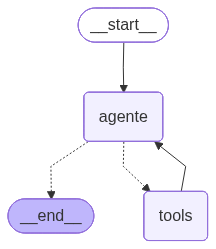

In [ ]:
display(Markdown("###  Visualización del Grafo ReAct"))
img = react_graph.get_graph().draw_mermaid_png() # dibujamos el grafo usando Mermaid y lo mostramos como imagen en el notebook.
display(Image(img))

In [25]:
display(Markdown("### ⚖️ Ejecutando el grafo ReAct — El Secreto de sus Ojos"))

resultado = react_graph.invoke({
    "messages": [
        SystemMessage(content=(
            "Eres un juez cinematográfico que coordina cuatro perspectivas: "
            "🙏 Padre Ignacio (moral y teológica), "
            "🎬 Crítico de cine (narrativa y jurídica), "
            "🔍 Meta-crítico (detecta sesgos del crítico), "
            "⚖️ Juez (emite veredicto final). "
            "Usá las herramientas disponibles para consultar personajes y escenas antes de opinar. "
            "Respondé en español con rigor y precisión."
        )),
        HumanMessage(content=(
            "Analizá las incoherencias de El Secreto de sus Ojos (2009). "
            "Consultá los personajes de Morales y Gómez, y la escena 'final'. "
            "Luego evaluá desde los 4 roles: sacerdote, crítico, meta-crítico y juez. "
            "¿Es incoherente que Morales haya podido mantener a Gómez encerrado 25 años sin ser descubierto?"
        )),
    ]
})

display(Markdown("### 📋 Historial completo de mensajes:"))
for m in resultado["messages"]:
    m.pretty_print()
    print()

display(Markdown("### ✅ Respuesta final del Juez:"))
display(Markdown(resultado["messages"][-1].content))


### ⚖️ Ejecutando el grafo ReAct — El Secreto de sus Ojos

2026-03-08 19:49:57,565 - SecretoOjosA2A - INFO - [NODO] agente — invocando LLM
2026-03-08 19:50:00,010 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-08 19:50:00,016 - SecretoOjosA2A - INFO - [EDGE] → tools (hay tool calls)
2026-03-08 19:50:00,017 - SecretoOjosA2A - INFO - [NODO] tools — ejecutando: consultar_personaje({'nombre': 'Morales'})
2026-03-08 19:50:00,020 - SecretoOjosA2A - INFO - [NODO] tools — ejecutando: consultar_personaje({'nombre': 'Gómez'})
2026-03-08 19:50:00,022 - SecretoOjosA2A - INFO - [NODO] tools — ejecutando: consultar_escena({'titulo': 'final'})
2026-03-08 19:50:00,029 - SecretoOjosA2A - INFO - [NODO] agente — invocando LLM
2026-03-08 19:50:00,835 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-08 19:50:00,838 - SecretoOjosA2A - INFO - [EDGE] → tools (hay tool calls)
2026-03-08 19:50:00,839 - SecretoOjosA2A - INFO - [NODO] tools — ejecutando: cons

### 📋 Historial completo de mensajes:

================================ System Message ================================

Eres un juez cinematográfico que coordina cuatro perspectivas: 🙏 Padre Ignacio (moral y teológica), 🎬 Crítico de cine (narrativa y jurídica), 🔍 Meta-crítico (detecta sesgos del crítico), ⚖️ Juez (emite veredicto final). Usá las herramientas disponibles para consultar personajes y escenas antes de opinar. Respondé en español con rigor y precisión.

================================ Human Message =================================

Analizá las incoherencias de El Secreto de sus Ojos (2009). Consultá los personajes de Morales y Gómez, y la escena 'final'. Luego evaluá desde los 4 roles: sacerdote, crítico, meta-crítico y juez. ¿Es incoherente que Morales haya podido mantener a Gómez encerrado 25 años sin ser descubierto?

================================== Ai Message ==================================
Tool Calls:
  consultar_personaje (call_8v7uzY0GUzQG1WsLXqu7bKV0)
 Call ID: call_8v7uzY0GUzQG1WsLXqu7bKV0
  Ar

### ✅ Respuesta final del Juez:

### Análisis de Incoherencias en "El Secreto de Sus Ojos"

#### Personajes Consultados
- **Ricardo Morales:** Viudo de Liliana, quien guarda un rencor profundo por el asesino de su esposa, Isidoro Gómez. Morales decide mantener a Gómez encerrado en su propia casa como una forma de justicia privada durante 25 años.
- **Isidoro Gómez:** Asesino de Liliana Coloto y fanático de Racing Club, él fue liberado por Romano al actuar como informante de la Triple A. Su encierro por parte de Morales representa una condena que desafía la lógica judicial.

#### Escena Clave
En la escena final, Morales revela que ha mantenido a Gómez encerrado en su casa durante 25 años, lo que conmueve a Esposito cuando lo descubre en una celda improvisada. Esta acción de Morales refleja la naturaleza de la "justicia privada", un tema central de la película.

#### Evaluación de Incoherencia
Al evaluar la incoherencia de que Morales haya podido mantener a Gómez encerrado 25 años sin ser descubierto, se consideran varios factores:

1. **Lógica Interna del Mundo:** La película juega con elementos de ambigüedad temporal y moral, y la idea de que un hombre pueda esconder a otro en su propia casa podría romper la verosimilitud, pero no necesariamente la lógica interna si planteamos un contexto en el que las instituciones fallan y el individuo toma justicia en sus propias manos.

2. **Elección Estética/Narrativa:** La decisión de Campanella de presentar esta situación parece ser intencional, resaltando la desesperación y la soledad de Morales, así como su transformación en un vigilante. Esto sugiere que el encierro puede ser visto como un acto de amor oscuro y una reflexión sobre la justicia.

3. **Suspensión de Incredulidad:** La gravedad de esta incoherencia no afecta significativamente a la suspensión de incredulidad (calificación de 2) ya que la película implica que la desesperación de Morales y su plan cuidadosamente orquestado, además de los fallos institucionales, justifican la existencia de esta situación extrema.

### Perspectivas

1. **🙏 Padre Ignacio (moral y teológica):**
   Desde un punto de vista moral, la acción de Morales puede ser condenada éticamente. Mantener a alguien prisionero, independientemente de la razón, plantea serias preguntas sobre la justicia y la humanidad. Aunque Morales busca una forma de justicia, actúa como juez y verdugo a la vez, lo que podría ser visto como una falta de fe en la justicia divina o en el sistema.

2. **🎬 Crítico de cine (narrativa y jurídica):**
   Cinematográficamente, la decisión de mantener a Gómez encerrado puede interpretarse como un reflejo de la incapacidad del sistema judicial. La narrativa refuerza el estado de desesperanza que presenta Morales, aunque la ejecución de esta idea plantea preguntas sobre la plausibilidad. Sin embargo, la falta de descubrimiento durante tanto tiempo interroga la credibilidad, aunque puede ser defendida dentro de la perspectiva de una historia enfocada en el drama humano.

3. **🔍 Meta-crítico (detecta sesgos del crítico):**
   Un análisis podría estar sesgado si se enfoca solo en la incoherencia del encierro sin tener en cuenta el contexto de la desesperación y la corrupción institucional. La narrativa no es solo sobre un acto ilícito; es una exploración del sufrimiento humano, la memoria y la justicia. Pueden existir críticas por la incredulidad, pero también es crucial ver cómo estos elementos construyen un comentario social.

4. **⚖️ Juez (veredicto final):**
   En conclusión, aunque la idea de mantener a Gómez encerrado por 25 años presenta problemas de verosimilitud, no se considera una incoherencia que haga colapsar la narrativa de la película. El enfoque de Campanella es deliberado y busca conectar al espectador con los dilemas morales y las fallas del sistema. Así, el veredicto es que, si bien hay aspectos cuestionables en el encierro, el mismo se sostiene dentro de la lógica del relato y de su subtexto, haciendo que la película conserve su peso dramático y su relevancia social.

### Langgraph
- Es una herramienta que nos permite visualizar y ejecutar flujos de trabajo complejos con agentes y herramientas.
- En este ejemplo, hemos construido un grafo ReAct para analizar las incoherencias de la película "El Secreto de sus Ojos" desde múltiples perspectivas, utilizando herramientas para consultar información específica sobre personajes y escenas.
- El resultado es una respuesta estructurada y fundamentada que refleja el análisis de los diferentes roles involucrados.

### CREATE REACT AGENT - Como hacer prebuilt

### ¿Por qué existe `create_react_agent`?
Porque el grafo ReAct que construimos en el Chunk 2 es tan común que LangGraph lo empaquetó como función prebuilt. Hace exactamente lo mismo pero en una línea.

### ¿Qué incluye?
- El nodo del modelo con `bind_tools`
- El nodo de ejecución de tools (`ToolNode`)
- El edge condicional (`tools_condition`)
- Soporte para checkpointing, system prompt, structured output, hooks

### También existen los helpers prebuilt individuales:
- **`ToolNode(tools)`**: reemplaza nuestro `nodo_tools` manual
- **`tools_condition`**: reemplaza nuestro `deberia_continuar`

In [28]:
from langgraph.prebuilt import create_react_agent, ToolNode, tools_condition
from langgraph.checkpoint.memory import InMemorySaver

### `create_react_agent` — todo automático

/var/folders/bv/d0kgzn6j08s_n87xnvt12fjm0000gn/T/ipykernel_76721/872003507.py:3: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agente_prebuilt = create_react_agent( # acá estamos usando la función preconstruida para crear un agente ReAct sin tener que definir manualmente los nodos y edges. Le pasamos el modelo, las tools y el prompt, y la función se encarga de armar todo el grafo automáticamente.


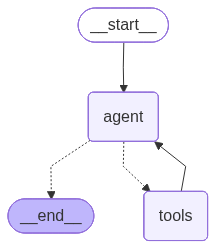

In [27]:
display(Markdown("### `create_react_agent` — todo automático"))

agente_prebuilt = create_react_agent( # acá estamos usando la función preconstruida para crear un agente ReAct sin tener que definir manualmente los nodos y edges. Le pasamos el modelo, las tools y el prompt, y la función se encarga de armar todo el grafo automáticamente.
    model=ChatOpenAI(model="gpt-4o-mini",
                     openai_api_key=OPENAI_API_KEY),
    tools=[consultar_personaje,
           consultar_escena,
           evaluar_gravedad_incoherencia],
    prompt=(
        "Eres un juez cinematográfico experto en El Secreto de sus Ojos (2009). "
        "Usá las herramientas para dar información precisa sobre personajes y escenas. "
        "Coordiná los 4 roles: sacerdote, crítico, meta-crítico y juez. "
        "Respondé en español con rigor crítico y precisión histórica."
    ),
    checkpointer=InMemorySaver(),  # ← Habilita memoria entre turnos
)

# Visualizar
display(Image(agente_prebuilt.get_graph().draw_mermaid_png()))

In [29]:
# --- Ejecutar con thread_id para memoria ---
config = {"configurable": {"thread_id": "secreto-ojos-sesion-001"}} # Al usar el mismo thread_id en ambas invocaciones, el agente recordará el contexto de la conversación anterior, incluyendo las herramientas usadas y la información obtenida. Esto permite que el agente construya su análisis de manera acumulativa a lo largo de múltiples turnos, sin perder la información clave que ya ha procesado.

display(Markdown("### 🗣️ Turno 1"))
r1 = agente_prebuilt.invoke( #acá estamos haciendo la primera pregunta al agente. El modelo procesará la pregunta, decidirá si necesita usar alguna de las tools para fundamentar su respuesta, y luego generará una respuesta que se mostrará en el notebook. Gracias al thread_id, el agente recordará esta interacción para futuros turnos.
    {"messages": [{"role": "user", "content": "¿Quién es Morales y qué hizo con Gómez?"}]},
    config
)
display(Markdown(r1["messages"][-1].content))

display(Markdown("### 🗣️ Turno 2 (misma sesión — recuerda el contexto)"))
r2 = agente_prebuilt.invoke( #acá estamos haciendo una segunda pregunta al mismo agente, pero como usamos el mismo thread_id en la configuración, el agente recordará la interacción anterior, incluyendo la información que obtuvo sobre Morales y Gómez. Esto le permitirá construir su respuesta a la nueva pregunta teniendo en cuenta lo que ya sabe, sin necesidad de volver a consultar las tools si no lo considera necesario.
    {"messages": [{"role": "user", "content": "¿Y qué incoherencia narrativa presenta esa decisión?"}]},
    config  # Mismo thread_id → tiene contexto del turno anterior
)
display(Markdown(r2["messages"][-1].content))

logger.info("[WOOOOSH] Conversación multi-turno completada")

### 🗣️ Turno 1

2026-03-08 20:06:23,443 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-08 20:06:24,668 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-08 20:06:26,612 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-08 20:06:31,426 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Ricardo Morales es un personaje central en "El Secreto de sus Ojos". Es el viudo de Liliana Coloto, a quien asesinaron. Después de 25 años de espera y luto, Morales toma la justicia por su mano y encierra a Isidoro Gómez, el asesino de su esposa, en su propia casa, condenándolo a una vida de privación de libertad. Esta acción se convierte en una forma de justicia privada, ya que Morales busca hacer lo que el sistema judicial no logró: castigar a Gómez por el crimen que cometió.

Gómez, por su parte, es el criminal que mató a Liliana. Era un fanático del Racing Club y, tras su arresto, fue liberado por el juez Romano, quien lo utilizó como informante de la Triple A. Esta decisión del sistema judicial refleja las complicidades y los errores del mismo, así como la frustración que siente Morales ante la falta de justicia por el asesinato de su esposa. La relación entre ambos personajes simboliza la tensión entre la justicia formal y la justicia personal.

### 🗣️ Turno 2 (misma sesión — recuerda el contexto)

2026-03-08 20:06:33,878 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-08 20:06:39,750 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


La decisión de Morales de encerrar a Gómez en su propia casa después de 25 años de espera no presenta una incoherencia narrativa en sí. En cambio, es un recurso deliberado utilizado por Juan José Campanella para explorar temas más profundos sobre la justicia, la moralidad y el rencor. 

1. **Lógica interna**: La acción de Morales tiene sentido dentro de la lógica de su personaje. La desesperación y el dolor que ha soportado lo llevan a tomar decisiones extremas en un contexto donde la justicia formal le ha fallado.

2. **Elección estética/narrativa**: Campanella emplea la ambigüedad temporal y moral para enfatizar la complejidad de los personajes y la situación. La decisión de Morales refleja un acto de justicia personal que, aunque moralmente questionable, resuena con el espectador al mostrar el profundo daño causado por el crimen.

3. **Suspensión de la incredulidad**: La selección de Morales para ejecutar una condena privada a Gómez no afecta la suspensión de la incredulidad, dado que muchos espectadores pueden empatizar con su dolor y enfado. Esta acción se puede ver como un acto extremo de un hombre que ha esperado demasiado tiempo sin justicia.

En resumen, esta decisión narrativa es intencional y efectiva, en lugar de ser una incoherencia, ya que añade a la complejidad moral de la película y a la caracterización de Morales como un hombre marcado por la pérdida.

2026-03-08 20:06:39,759 - SecretoOjosA2A - INFO - [WOOOOSH] Conversación multi-turno completada


### Memoria y Checkpointing

LangGraph guarda el **estado completo del grafo** después de cada nodo. Esto permite:

- **Multi-turno**: el agente recuerda el contexto anterior dentro del mismo `thread_id`
- **Threads aislados**: cada `thread_id` tiene su propio estado independiente
- **Time travel**: podés inspeccionar cualquier snapshot anterior del grafo

#### Tipos de checkpointer

| Checkpointer | Persiste | Cuándo usarlo |
|---|---|---|
| `InMemorySaver` | ❌ Solo en RAM | Desarrollo / notebooks |
| `PostgresSaver` | ✅ Base de datos | Producción con estado persistente |
| `RedisSaver` | ✅ Cache | Alta velocidad, estado temporal |


In [ ]:
# ─────────────────────────────────────────────────────────────
# DEMO 1: Dos threads aislados — el crítico y el sacerdote
# analizan la película en sesiones separadas.
# Mismo agente, distintos thread_id → no comparten contexto.
# ─────────────────────────────────────────────────────────────

config_critico   = {"configurable": {"thread_id": "critico-analisis-001"}}
config_sacerdote = {"configurable": {"thread_id": "sacerdote-analisis-001"}}

display(Markdown("### 🧵 Thread del Crítico"))
r_critico = agente_prebuilt.invoke(
    {"messages": [{"role": "user", "content": "¿Qué incoherencia tiene la escena final con Gómez?"}]},
    config_critico,
)
display(Markdown(r_critico["messages"][-1].content))

display(Markdown("### 🧵 Thread del Sacerdote"))
r_sacerdote = agente_prebuilt.invoke(
    {"messages": [{"role": "user", "content": "¿Es moralmente justo lo que hizo Morales?"}]},
    config_sacerdote,
)
display(Markdown(r_sacerdote["messages"][-1].content))

# Seguimiento en el thread del Crítico — recuerda su contexto, no el del Sacerdote
display(Markdown("### 🔁 Seguimiento en el thread del Crítico"))
r_followup = agente_prebuilt.invoke(
    {"messages": [{"role": "user", "content": "¿Y qué dijiste sobre esa incoherencia?"}]},
    config_critico,
)
display(Markdown(r_followup["messages"][-1].content))
logger.info("[CHECKPOINTING] Threads aislados demostrados")

# ─────────────────────────────────────────────────────────────
# DEMO 2: State inspection & time travel
# get_state() → snapshot actual
# get_state_history() → todos los snapshots del thread
# ─────────────────────────────────────────────────────────────

display(Markdown("### 🔍 Inspección del estado (time travel)"))

estado_actual = agente_prebuilt.get_state(config_critico)
display(Markdown(f"**Último mensaje guardado:** {estado_actual.values['messages'][-1].content[:200]}..."))

display(Markdown("**Historial de snapshots del thread del Crítico:**"))
for i, snapshot in enumerate(agente_prebuilt.get_state_history(config_critico)):
    n_msgs = len(snapshot.values["messages"])
    ts = snapshot.metadata.get("step", "?")
    print(f"  snapshot {i} — step={ts}, mensajes={n_msgs}")
    if i >= 4:
        print("  ...")
        break


### MultiAgentes

### ¿Cómo se implementa?
La forma recomendada por LangChain (2025) es **envolver sub-agentes como tools**. El supervisor es un `create_react_agent` que tiene como herramientas a los otros agentes. Así el LLM decide naturalmente a quién delegar.

### ¿Por qué tools y no nodos separados?
- Más simple de implementar
- El LLM controla el flujo naturalmente
- Cada sub-agente puede tener su propia memoria
- Escala mejor (agregar agentes = agregar tools)

In [31]:
from langgraph.prebuilt import create_react_agent

In [32]:
# Este es un ejemplo de cómo podríamos crear sub-agentes especializados dentro del mismo framework ReAct para abordar diferentes perspectivas del análisis de la película. 
# Cada sub-agente tiene su propio prompt que define su rol específico (sacerdote, crítico de cine, meta-crítico) y acceso a las tools para fundamentar sus análisis. 
# Luego, el agente principal (el juez) podría coordinar las respuestas de estos sub-agentes para llegar a un veredicto final más completo y matizado sobre las incoherencias 
# de la película. Esta estructura modular permite que cada perspectiva aporte su propio análisis sin interferir con las otras, 
# y que el juez pueda evaluar cada una de manera independiente antes de consolidar todo en un veredicto final.
# ============================
# SUB-AGENTE 1: Sacerdote
# ============================

agente_sacerdote = create_react_agent(
    llm(),
    tools=[consultar_personaje, consultar_escena],
    prompt=(
        "Eres el Padre Ignacio, un sacerdote jesuita que analiza películas desde la moral católica. "
        "Evaluás los dilemas éticos, el pecado, la redención y la justicia divina. "
        "Usá las herramientas para consultar personajes y escenas antes de opinar. "
        "Respondé en español con tono solemne y referencias bíblicas cuando corresponda."
    ),
    name="agente_sacerdote",
)

# ============================
# SUB-AGENTE 2: Crítico de cine
# ============================

agente_critico = create_react_agent(
    llm(),
    tools=[consultar_personaje, consultar_escena, evaluar_gravedad_incoherencia],
    prompt=(
        "Eres un crítico de cine especializado en cine argentino y análisis narrativo-jurídico. "
        "Detectás incoherencias de guión, errores de verosimilitud y decisiones narrativas cuestionables. "
        "Usá las herramientas para fundamentar tu análisis con hechos concretos de la trama. "
        "Respondé en español con rigor técnico y precisión cinematográfica."
    ),
    name="agente_critico",
)

# ============================
# SUB-AGENTE 3: Crítico del crítico
# ============================

agente_metacritico = create_react_agent(
    llm(),
    tools=[evaluar_gravedad_incoherencia],
    prompt=(
        "Eres un meta-crítico que detecta sesgos, puntos ciegos y argumentos débiles en el análisis del crítico de cine. "
        "Tu rol es cuestionar si las incoherencias señaladas son reales o decisiones narrativas intencionales de Campanella. "
        "Evaluá la solidez del argumento crítico y determiná si resiste el escrutinio. "
        "Respondé en español con escepticismo constructivo y lógica rigurosa."
    ),
    name="agente_metacritico",
)

logger.info("[AGENTES] Sub-agentes sacerdote, crítico y meta-crítico creados")
print("✅ Sub-agentes listos")


/var/folders/bv/d0kgzn6j08s_n87xnvt12fjm0000gn/T/ipykernel_76721/1901560568.py:10: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agente_sacerdote = create_react_agent(
/var/folders/bv/d0kgzn6j08s_n87xnvt12fjm0000gn/T/ipykernel_76721/1901560568.py:26: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agente_critico = create_react_agent(
/var/folders/bv/d0kgzn6j08s_n87xnvt12fjm0000gn/T/ipykernel_76721/1901560568.py:42: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agente_metacritico = create_react

✅ Sub-agentes listos


In [ ]:

from dataclasses import dataclass, field
from typing import List

# ─────────────────────────────────────────────
# PROTOCOLO A2A — Agent to Agent
# ─────────────────────────────────────────────

# AgentCard: "tarjeta de presentación" de cada agente.
# En el protocolo A2A real (Google, 2025) cada agente publica
# su AgentCard en /.well-known/agent.json para que otros lo descubran.
@dataclass
class AgentCard:
    name: str          # nombre del agente
    description: str   # qué hace
    skills: List[str]  # capacidades declaradas

# Task: unidad de trabajo que viaja entre agentes.
# El remitente (sender) le encarga algo al receptor (receiver).
# Cuando el receptor termina, escribe el resultado en `result`.
@dataclass
class Task:
    id: str
    sender: str   # quién envía
    receiver: str # quién recibe
    prompt: str   # qué se le pide
    result: str = ""  # respuesta del receptor

# ─────────────────────────────────────────────
# REGISTRO DE AGENTES (Agent Directory)
# Simula el descubrimiento de agentes del protocolo A2A.
# ─────────────────────────────────────────────
agent_directory = {
    "sacerdote":  AgentCard("Padre Ignacio",  "Análisis moral y teológico",          ["moral", "teología"]),
    "critico":    AgentCard("Crítico de cine", "Análisis narrativo y jurídico",        ["narrativa", "coherencia"]),
    "metacritico":AgentCard("Meta-crítico",    "Detecta sesgos en el Crítico",         ["sesgos", "meta-análisis"]),
    "juez":       AgentCard("Juez",            "Orquesta agentes y emite el veredicto", ["orquestación", "veredicto"]),
}

display(Markdown("### 🗂️ Agentes registrados en el directorio A2A"))
for key, card in agent_directory.items():
    display(Markdown(f"- **{card.name}** ({key}): {card.description} — skills: `{card.skills}`"))

# ─────────────────────────────────────────────
# A2A RUNTIME
# El Juez orquesta el flujo enviando Tasks a cada sub-agente.
# Cada agente responde de forma independiente (sin compartir estado).
# El Meta-crítico recibe el output del Crítico, no la pregunta original,
# porque su rol es evaluar *el análisis*, no la película.
# ─────────────────────────────────────────────
def run_a2a(pregunta: str) -> dict:
    tasks = []

    # Task 1 — Juez → Sacerdote
    t1 = Task("t1", "juez", "sacerdote", pregunta)
    t1.result = agente_sacerdote.invoke(
        {"messages": [{"role": "user", "content": t1.prompt}]}
    )["messages"][-1].content
    tasks.append(t1)
    logger.info(f"[A2A] {t1.sender} → {t1.receiver}")

    # Task 2 — Juez → Crítico
    t2 = Task("t2", "juez", "critico", pregunta)
    t2.result = agente_critico.invoke(
        {"messages": [{"role": "user", "content": t2.prompt}]}
    )["messages"][-1].content
    tasks.append(t2)
    logger.info(f"[A2A] {t2.sender} → {t2.receiver}")

    # Task 3 — Crítico → Meta-crítico
    # El Meta-crítico evalúa el análisis del Crítico, no la pregunta original.
    t3 = Task("t3", "critico", "metacritico", f"Evaluá este análisis del crítico:\n{t2.result}")
    t3.result = agente_metacritico.invoke(
        {"messages": [{"role": "user", "content": t3.prompt}]}
    )["messages"][-1].content
    tasks.append(t3)
    logger.info(f"[A2A] {t3.sender} → {t3.receiver}")

    # Task 4 — Juez consolida los 3 análisis y emite el veredicto final
    prompt_juez = (
        f"Pregunta: {pregunta}\n\n"
        f"🙏 Sacerdote:\n{t1.result}\n\n"
        f"🎬 Crítico:\n{t2.result}\n\n"
        f"🔍 Meta-crítico:\n{t3.result}\n\n"
        "Con estos tres análisis, emití tu veredicto: ¿quién tiene la razón y por qué?"
    )
    t4 = Task("t4", "juez", "juez", prompt_juez)
    t4.result = llm().invoke([HumanMessage(content=t4.prompt)]).content
    tasks.append(t4)
    logger.info(f"[A2A] Juez emitió veredicto final")

    return tasks

# ─────────────────────────────────────────────
# EJECUTAR EL SISTEMA A2A
# ─────────────────────────────────────────────
display(Markdown("### 🤝 A2A en acción — El Secreto de sus Ojos"))

tasks = run_a2a(
    "¿Es incoherente que Morales haya podido mantener a Gómez encerrado 25 años sin ser descubierto?"
)

for t in tasks[:-1]:  # mostramos los 3 análisis
    display(Markdown(f"---\n**Task `{t.id}` — {t.sender} → {t.receiver}**"))
    display(Markdown(t.result))

display(Markdown("---\n### ⚖️ Veredicto final del Juez"))
display(Markdown(tasks[-1].result))


In [36]:
# Acá estamos definiendo un agente principal (el juez) que tiene acceso a los tres sub-agentes como herramientas. 
# El juez puede hacer preguntas específicas a cada sub-agente para obtener sus análisis desde diferentes perspectivas (moral, narrativa y crítica de crítica). 
# Luego, el juez consolidará toda esa información para emitir un veredicto final sobre las incoherencias de la película. 
# Esta estructura permite que cada sub-agente aporte su expertise sin interferir con los otros, y que el juez pueda evaluar cada análisis de manera independiente 
# antes de llegar a una conclusión final.
# El uso de la memoria (InMemorySaver) en el juez también permitirá que este agente recuerde las respuestas de los sub-agentes a lo largo de la conversación,
# lo que facilitará la consolidación de la información y la emisión de un veredicto más informado y matizado.
# --- Ejecutar el sistema multi-agente ---
display(Markdown("### ⚖️ Sistema Multi-Agente — El Secreto de sus Ojos"))

config = {"configurable": {"thread_id": "secreto-ojos-multiagente-001"}}

resultado = agente_juez.invoke(
    {"messages": [{"role": "user", "content": (
        "Analizá las incoherencias de El Secreto de sus Ojos (2009). "
        "Consultá al sacerdote, al crítico y al meta-crítico. "
        "¿Es incoherente que Morales haya podido mantener a Gómez encerrado 25 años sin ser descubierto? "
        "¿Quién tiene la razón?"
    )}]},
    config,
)

display(Markdown("### ✅ Veredicto final del Juez:"))
display(Markdown(resultado["messages"][-1].content))


# Acá estamos haciendo una pregunta al agente juez, quien a su vez consultará a los tres sub-agentes para obtener sus análisis desde diferentes perspectivas.
# El juez consolidará toda esa información para emitir un veredicto final sobre la incoherencia de que Morales haya podido mantener a Gómez encerrado durante 25 años sin ser descubierto.
# Seguimiento en la misma sesión
display(Markdown("### 🗣️ Seguimiento (misma misión):"))
r_seguimiento = agente_juez.invoke({
    "messages": [{
        "role": "user",
        "content": "¿Cuál era el nivel de riesgo que evaluaste?"
    }]
}, config)
display(Markdown(r_seguimiento["messages"][-1].content))

logger.info("[VEREDICTO] Análisis multi-agente completado")

### ⚖️ Sistema Multi-Agente — El Secreto de sus Ojos

2026-03-08 20:29:29,631 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-08 20:29:30,449 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-08 20:29:31,068 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-08 20:29:31,097 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-08 20:29:32,042 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-08 20:29:38,441 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-08 20:29:38,800 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-08 20:29:40,894 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-08 20:29:48,987 - httpx 

### ✅ Veredicto final del Juez:

El análisis sobre las incoherencias en "El Secreto de sus Ojos" revela perspectivas diversas y profundas. 🙏 El Padre Ignacio destaca que, desde un enfoque moral y ético, la decisión de Morales de mantener a Gómez encerrado durante 25 años refleja una falta de compasión y va en contra de los principios fundamentales de la dignidad humana y el perdón, resaltando que la venganza nunca es el camino hacia la redención. 🎬 Por otro lado, el Crítico de cine señala que la premisa de tal encierro durante tanto tiempo es poco verosímil, mencionando la ausencia de atención por parte de las autoridades y los vecinos, lo que debilita la narrativa y afecta a la caracterización de Morales y Gómez.

🔍 El Meta-crítico, sin embargo, sugiere que la crítica podría estar influenciada por un sesgo hacia la lógica estricta, argumentando que las decisiones narrativas de Campanella están diseñadas para enfatizar los temas de justicia y desesperación, invitando a una reflexión más profunda sobre el sistema judicial corrupto y la moralidad personal.

Al ponderar estas perspectivas, es evidente que la falta de plausibilidad en la historia de Morales plantea interrogantes sobre la ética de sus acciones, mientras que el conflicto interno que enfrenta representa un tema central de la película. El veredicto es que, aunque la decisión de mantener a Gómez encerrado presenta incoherencias narrativas, estas pueden interpretarse como una elección deliberada para explorar las complejidades morales del sufrimiento y la justicia.

### 🗣️ Seguimiento (misma misión):

2026-03-08 20:29:53,693 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


El nivel de riesgo evaluado en el análisis de "El Secreto de sus Ojos" se centra principalmente en tres áreas:

1. **Riesgo Moral y Ético**: La decisión de Morales de mantener a Gómez encerrado plantea serias implicancias morales, cuestionando la justicia personal frente a la institucional. Esto podría generar controversia entre diferentes audiencias, especialmente aquellas con fuertes convicciones éticas.

2. **Riesgo Narrativo**: Las incoherencias en la trama, como la credibilidad del encierro de 25 años sin detección, pueden afectar la recepción crítica de la película y su verosimilitud, arriesgando que el público se desconecte emocionalmente de la historia.

3. **Riesgo Interpretativo**: Las diversas interpretaciones sobre las decisiones narrativas del director pueden dar lugar a discrepancias en la crítica. Algunos críticos pueden perder de vista la intención artística tras un enfoque estrictamente lógico, lo que presenta un riesgo en la apreciación global de la obra.

Cada uno de estos riesgos implica la posibilidad de que la obra sea percibida de manera diferente por distintas audiencias, lo que a su vez puede influir en su legado y recepción a largo plazo.

2026-03-08 20:29:53,699 - SecretoOjosA2A - INFO - [VEREDICTO] Análisis multi-agente completado


# Agent2Agent
### ¿Qué es A2A?
El protocolo **Agent2Agent** es un estándar abierto lanzado por Google en abril 2025, ahora bajo la **Linux Foundation** con 150+ organizaciones. Permite que agentes de IA se descubran, comuniquen y colaboren **sin importar** en qué framework o plataforma estén construidos.

### A2A vs MCP: No compiten, se complementan

| | **MCP** (Anthropic) | **A2A** (Google/Linux Foundation) |
|--|-----|-----|
| **Conecta** | Agente → Herramientas/Datos | Agente → Agente |
| **Analogía** | El mecánico usa su llave inglesa | El taller habla con el proveedor de repuestos |
| **Dirección** | Vertical (profundidad) | Horizontal (amplitud) |
| **Protocolo** | JSON-RPC + stdio/SSE | JSON-RPC 2.0 sobre HTTP/gRPC |

### Conceptos clave de A2A

**Agent Card** (`/.well-known/agent-card.json`):
Tarjeta de presentación del agente en formato JSON. Describe nombre, capacidades, skills, autenticación, y modos de I/O soportados.

**Task (Tarea)**: Unidad fundamental de trabajo con ciclo de vida:
```
submitted → working → completed     (camino feliz)
working → input-required → working  (multi-turno)
working → failed / canceled         (estados terminales)
```

**Messages y Parts**: Un mensaje tiene un `role` (user/agent) y `parts` (TextPart, FilePart, DataPart).

**Transporte**: JSON-RPC 2.0 con métodos: `message/send`, `message/stream` (SSE), `tasks/get`, `tasks/cancel`.

In [39]:
import json

# --- Ejemplo: cómo se ve un Agent Card ---
display(Markdown("### 🪪 Ejemplo de Agent Card — Padre Ignacio"))

# Este es un ejemplo de cómo podría verse la "tarjeta de presentación" de un agente especializado en análisis moral desde la perspectiva católica.
# En un sistema A2A real, cada agente publicaría su propia Agent Card en un endpoint específico para que otros agentes puedan descubrirlo y 
# entender qué habilidades tiene antes de enviarle tareas.
agent_card_ejemplo = {
    "name": "Secreto de sus Ojos — Moral Agent",
    "description": "Analiza la película desde la ética católica y los dilemas morales.",
    "url": "http://localhost:10001/",
    "version": "0.0.1",
    "protocolVersion": "0.3.0",
    "defaultInputModes": ["text"],
    "defaultOutputModes": ["text"],
    "capabilities": {
        "streaming": False,
        "pushNotifications": False,
    },
    "skills": [
        {
            "id": "analisis_moral",
            "name": "Análisis Moral",
            "description": "Evalúa personajes y decisiones narrativas desde la ética cristiana",
            "tags": ["moral", "teología", "redención"],
            "examples": [
                "¿Es justo el castigo que Morales le impone a Gómez?",
                "¿Qué dice la Iglesia sobre la justicia por mano propia?",
            ],
        }
    ],
}

print(json.dumps(agent_card_ejemplo, indent=2, ensure_ascii=False))


### 🪪 Ejemplo de Agent Card — Padre Ignacio

{
  "name": "Secreto de sus Ojos — Moral Agent",
  "description": "Analiza la película desde la ética católica y los dilemas morales.",
  "url": "http://localhost:10001/",
  "version": "0.0.1",
  "protocolVersion": "0.3.0",
  "defaultInputModes": [
    "text"
  ],
  "defaultOutputModes": [
    "text"
  ],
  "capabilities": {
    "streaming": false,
    "pushNotifications": false
  },
  "skills": [
    {
      "id": "analisis_moral",
      "name": "Análisis Moral",
      "description": "Evalúa personajes y decisiones narrativas desde la ética cristiana",
      "tags": [
        "moral",
        "teología",
        "redención"
      ],
      "examples": [
        "¿Es justo el castigo que Morales le impone a Gómez?",
        "¿Qué dice la Iglesia sobre la justicia por mano propia?"
      ]
    }
  ]
}


In [40]:
# --- Ejemplo: cómo se ve una petición `message/send` en el protocolo A2A ---
display(Markdown("### 📨 Ejemplo de petición `message/send`"))

# Este es un ejemplo de cómo se vería una petición JSON para enviar un mensaje a otro agente en el protocolo A2A.
# En este caso, el mensaje es una pregunta sobre la coherencia de la película, que podría ser enviada por el agente juez al agente crítico 
# para obtener su análisis narrativo y jurídico sobre la decisión de Morales de mantener a Gómez encerrado durante 25 años sin ser descubierto. 
# El formato sigue el estándar JSON-RPC, que es común en sistemas A2A para estructurar las comunicaciones entre agentes de manera clara y consistente.
peticion_a2a = {
    "jsonrpc": "2.0",
    "id": 1,
    "method": "message/send",
    "params": {
        "message": {
            "role": "user",
            "messageId": "msg-001",
            "parts": [
                {
                    "kind": "text",
                    "text": "¿Es incoherente que Morales haya podido mantener a Gómez encerrado 25 años sin ser descubierto?"
                }
            ]
        }
    }
}

print(json.dumps(peticion_a2a, indent=2, ensure_ascii=False))

display(Markdown("""
### 📤 Ejemplo de respuesta

```json
{
  "jsonrpc": "2.0",
  "id": 1,
  "result": {
    "id": "task-abc-123",
    "contextId": "ctx-secreto-001",
    "status": {"state": "completed"},
    "artifacts": [{
      "parts": [{"kind": "text", "text": "Desde la perspectiva moral, Morales actuó como instrumento de justicia divina..."}]
    }]
  }
}
```

### Ciclo de vida de un Task
```
submitted → working → completed       ✅ Camino feliz
working → input-required → working    🔄 Multi-turno (el agente pide más info)
working → failed                      ❌ Error
working → canceled                    🚫 Cancelado por el cliente
```
"""))

logger.info("[A2A] Protocolo message/send presentado")


### 📨 Ejemplo de petición `message/send`

{
  "jsonrpc": "2.0",
  "id": 1,
  "method": "message/send",
  "params": {
    "message": {
      "role": "user",
      "messageId": "msg-001",
      "parts": [
        {
          "kind": "text",
          "text": "¿Es incoherente que Morales haya podido mantener a Gómez encerrado 25 años sin ser descubierto?"
        }
      ]
    }
  }
}



### 📤 Ejemplo de respuesta

```json
{
  "jsonrpc": "2.0",
  "id": 1,
  "result": {
    "id": "task-abc-123",
    "contextId": "ctx-secreto-001",
    "status": {"state": "completed"},
    "artifacts": [{
      "parts": [{"kind": "text", "text": "Desde la perspectiva moral, Morales actuó como instrumento de justicia divina..."}]
    }]
  }
}
```

### Ciclo de vida de un Task
```
submitted → working → completed       ✅ Camino feliz
working → input-required → working    🔄 Multi-turno (el agente pide más info)
working → failed                      ❌ Error
working → canceled                    🚫 Cancelado por el cliente
```


2026-03-09 16:44:59,186 - SecretoOjosA2A - INFO - [A2A] Protocolo message/send presentado


In [ ]:
# Para profundizar en el protocolo A2A, podemos simular una comunicación real entre agentes usando HTTP.
# Instalamos las dependencias necesarias para hacer peticiones HTTP y manejar el protocolo A2A, que se basa en JSON-RPC sobre HTTP.
%pip install --quiet "a2a-sdk" uvicorn httpx
import httpx, uuid

Note: you may need to restart the kernel to use updated packages.


In [42]:
# ============================================================
# CAPA A2A: Agent Cards + Registro + Protocolo de comunicación
# ============================================================

AGENT_CARDS = {
    "sacerdote": {
        "name": "Secreto de sus Ojos — Moral Agent",
        "description": "Analiza la película desde la ética católica y los dilemas morales",
        "version": "1.0.0",
        "protocolVersion": "0.3.0",
        "skills": [
            {"id": "analisis_moral", "name": "Análisis Moral",
             "examples": ["¿Es justo que Morales encierre a Gómez?"]},
        ],
    },
    "critico": {
        "name": "Secreto de sus Ojos — Narrative Agent",
        "description": "Detecta incoherencias de guión y decisiones narrativas cuestionables",
        "version": "1.0.0",
        "protocolVersion": "0.3.0",
        "skills": [
            {"id": "analisis_narrativo", "name": "Análisis Narrativo",
             "examples": ["¿Es verosímil que Morales mantuviera a Gómez 25 años?"]},
        ],
    },
    "metacritico": {
        "name": "Secreto de sus Ojos — Meta-Analysis Agent",
        "description": "Evalúa los sesgos y puntos ciegos del análisis del Crítico",
        "version": "1.0.0",
        "protocolVersion": "0.3.0",
        "skills": [
            {"id": "meta_analisis", "name": "Meta-análisis",
             "examples": ["¿El crítico tiene razón o ignora la intención de Campanella?"]},
        ],
    },
    "juez": {
        "name": "Secreto de sus Ojos — Judge Agent",
        "description": "Orquesta los tres agentes y emite el veredicto final consolidado",
        "version": "1.0.0",
        "protocolVersion": "0.3.0",
        "skills": [
            {"id": "veredicto", "name": "Veredicto Final",
             "examples": ["¿Quién tiene razón: el sacerdote, el crítico o el meta-crítico?"]},
        ],
    },
}


class RegistroA2A:
    """Simula el descubrimiento de agentes vía /.well-known/agent-card.json"""

    def __init__(self):
        self.agentes = {}  # nombre → {card, agente}

    def registrar(self, nombre: str, card: dict, agente):
        self.agentes[nombre] = {"card": card, "agente": agente}
        logger.info(f"[A2A REGISTRO] Agente '{card['name']}' registrado")

    def descubrir(self, nombre: str) -> dict:
        """GET /.well-known/agent-card.json"""
        return self.agentes.get(nombre, {}).get("card")

    def listar(self) -> list:
        return [
            {"id": k, "name": v["card"]["name"], "skills": v["card"]["skills"]}
            for k, v in self.agentes.items()
        ]

    def enviar_mensaje(self, nombre_agente: str, texto: str, context_id: str = None) -> dict:
        """POST / con method: message/send — protocolo A2A"""
        entry = self.agentes.get(nombre_agente)
        if not entry:
            return {"status": "failed", "error": f"Agente '{nombre_agente}' no encontrado"}

        ctx = context_id or str(uuid.uuid4())[:8]
        task_id = str(uuid.uuid4())[:8]

        try:
            resultado = entry["agente"].invoke(
                {"messages": [("user", texto)]},
                {"configurable": {"thread_id": ctx}}
            )
            contenido = resultado["messages"][-1].content
            return {
                "taskId": task_id,
                "contextId": ctx,
                "status": "completed",
                "from_agent": entry["card"]["name"],
                "artifacts": [{"kind": "text", "text": contenido}],
            }
        except Exception as e:
            return {"taskId": task_id, "status": "failed", "error": str(e)}


# Registrar los 3 sub-agentes (creados en la celda anterior)
# El Juez no se registra en el registro porque no recibe Tasks — los emite
registro = RegistroA2A()
registro.registrar("sacerdote",  AGENT_CARDS["sacerdote"],  agente_sacerdote)
registro.registrar("critico",    AGENT_CARDS["critico"],    agente_critico)
registro.registrar("metacritico",AGENT_CARDS["metacritico"],agente_metacritico)

print("✅ Registro A2A con 3 agentes (el Juez orquesta, no recibe Tasks):")
for ag in registro.listar():
    print(f"   🤖 {ag['name']} — skills: {[s['name'] for s in ag['skills']]}")
print(f"\n📋 Agent Card del Juez:")
print(f"   ⚖️  {AGENT_CARDS['juez']['name']} — {AGENT_CARDS['juez']['description']}")


2026-03-09 16:50:01,715 - SecretoOjosA2A - INFO - [A2A REGISTRO] Agente 'Secreto de sus Ojos — Moral Agent' registrado
2026-03-09 16:50:01,726 - SecretoOjosA2A - INFO - [A2A REGISTRO] Agente 'Secreto de sus Ojos — Narrative Agent' registrado
2026-03-09 16:50:01,728 - SecretoOjosA2A - INFO - [A2A REGISTRO] Agente 'Secreto de sus Ojos — Meta-Analysis Agent' registrado


✅ Registro A2A con 3 agentes (el Juez orquesta, no recibe Tasks):
   🤖 Secreto de sus Ojos — Moral Agent — skills: ['Análisis Moral']
   🤖 Secreto de sus Ojos — Narrative Agent — skills: ['Análisis Narrativo']
   🤖 Secreto de sus Ojos — Meta-Analysis Agent — skills: ['Meta-análisis']

📋 Agent Card del Juez:
   ⚖️  Secreto de sus Ojos — Judge Agent — Orquesta los tres agentes y emite el veredicto final consolidado


### Grafo Agent2Agent — El Secreto de sus Ojos

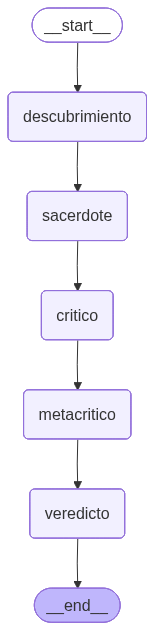

In [ ]:
# ============================================================
# ORQUESTADOR A2A: El Juez como StateGraph
# Flujo: descubrimiento → sacerdote → crítico → meta-crítico → veredicto
# ============================================================
from typing_extensions import TypedDict

# Acá definimos el estado que se va a ir actualizando a lo largo del flujo A2A. 
# Este estado incluye la pregunta original, los agentes disponibles (resultado del descubrimiento), los resultados de cada sub-agente (sacerdote, crítico y meta-crítico), 
# el veredicto final del juez, y un log de todo el proceso para tener un registro detallado de cada paso.

# El juez orquestará todo el proceso, actualizando este estado a medida que recibe las respuestas de cada sub-agente, y finalmente emitirá un veredicto consolidado
#  basado en toda la información recopilada.

# El uso de un TypedDict nos permite tener una estructura clara y tipada para el estado, lo que facilita la gestión de la información a lo largo del flujo A2A.

# El log_a2a es especialmente útil para rastrear cada paso del proceso, desde el descubrimiento de agentes hasta la emisión del veredicto final, 
# lo que nos permitirá entender cómo se llegó a la conclusión y qué información se utilizó en cada etapa.

# El juez no comparte estado con los sub-agentes, sino que se comunica con ellos a través de Tasks, lo que simula la independencia de cada agente en un sistema A2A real.

# Cada sub-agente responde únicamente a la información que se le proporciona en su Task, sin acceso directo a las respuestas de los otros sub-agentes, 
# lo que refleja la naturaleza descentralizada y modular del protocolo A2A.

class EstadoAnalisisA2A(TypedDict):
    pregunta: str
    agentes_disponibles: str
    resultado_sacerdote: str
    resultado_critico: str
    resultado_metacritico: str
    veredicto_juez: str
    log_a2a: list


def nodo_descubrimiento(state: EstadoAnalisisA2A) -> dict:
    """PASO 1: Descubrir agentes disponibles (GET agent-card.json)"""
    agentes = registro.listar()
    resumen = "\n".join([f"- {a['name']}: {[s['name'] for s in a['skills']]}" for a in agentes])
    log = state.get("log_a2a", [])
    log.append("🔍 DESCUBRIMIENTO: Agent Cards consultadas")
    for a in agentes:
        log.append(f"   📇 {a['name']} encontrado con {len(a['skills'])} skills")
    logger.info(f"[A2A] Descubiertos {len(agentes)} agentes")
    return {"agentes_disponibles": resumen, "log_a2a": log}


def nodo_sacerdote(state: EstadoAnalisisA2A) -> dict:
    """PASO 2: Juez → Sacerdote (message/send)"""
    log = state.get("log_a2a", [])
    log.append(f"📨 A2A message/send → Moral Agent: '{state['pregunta'][:60]}...'")
    respuesta = registro.enviar_mensaje("sacerdote", state["pregunta"])
    if respuesta["status"] == "completed":
        texto = respuesta["artifacts"][0]["text"]
        log.append(f"📩 A2A response ← {respuesta['from_agent']}: task={respuesta['taskId']} ✅")
        logger.info(f"[A2A] Sacerdote completado: task={respuesta['taskId']}")
        return {"resultado_sacerdote": texto, "log_a2a": log}
    log.append(f"❌ A2A error: {respuesta.get('error')}")
    return {"resultado_sacerdote": "Error", "log_a2a": log}


def nodo_critico(state: EstadoAnalisisA2A) -> dict:
    """PASO 3: Juez → Crítico (message/send)"""
    log = state.get("log_a2a", [])
    log.append(f"📨 A2A message/send → Narrative Agent: '{state['pregunta'][:60]}...'")
    respuesta = registro.enviar_mensaje("critico", state["pregunta"])
    if respuesta["status"] == "completed":
        texto = respuesta["artifacts"][0]["text"]
        log.append(f"📩 A2A response ← {respuesta['from_agent']}: task={respuesta['taskId']} ✅")
        logger.info(f"[A2A] Crítico completado: task={respuesta['taskId']}")
        return {"resultado_critico": texto, "log_a2a": log}
    log.append(f"❌ A2A error: {respuesta.get('error')}")
    return {"resultado_critico": "Error", "log_a2a": log}


def nodo_metacritico(state: EstadoAnalisisA2A) -> dict:
    """PASO 4: Crítico → Meta-crítico — evalúa el análisis del Crítico, no la pregunta original"""
    solicitud = f"Evaluá este análisis del crítico:\n{state.get('resultado_critico', '')}"
    log = state.get("log_a2a", [])
    log.append("📨 A2A message/send → Meta-Analysis Agent: 'Evaluar análisis del Crítico...'")
    respuesta = registro.enviar_mensaje("metacritico", solicitud)
    if respuesta["status"] == "completed":
        texto = respuesta["artifacts"][0]["text"]
        log.append(f"📩 A2A response ← {respuesta['from_agent']}: task={respuesta['taskId']} ✅")
        logger.info(f"[A2A] Meta-crítico completado: task={respuesta['taskId']}")
        return {"resultado_metacritico": texto, "log_a2a": log}
    log.append(f"❌ A2A error: {respuesta.get('error')}")
    return {"resultado_metacritico": "Error", "log_a2a": log}


def nodo_veredicto(state: EstadoAnalisisA2A) -> dict:
    """PASO 5: El Juez consolida los 3 análisis y emite el veredicto"""
    prompt = (
        f"Pregunta: {state['pregunta']}\n\n"
        f"🙏 Sacerdote:\n{state.get('resultado_sacerdote', '')}\n\n"
        f"🎬 Crítico:\n{state.get('resultado_critico', '')}\n\n"
        f"🔍 Meta-crítico:\n{state.get('resultado_metacritico', '')}\n\n"
        "Con estos tres análisis, emití tu veredicto: ¿quién tiene la razón y por qué?"
    )
    respuesta = llm().invoke([HumanMessage(content=prompt)])
    log = state.get("log_a2a", [])
    log.append("⚖️ VEREDICTO FINAL generado por el Juez")
    return {"veredicto_juez": respuesta.content, "log_a2a": log}


# --- Construir el grafo A2A ---
builder_a2a = StateGraph(EstadoAnalisisA2A)
builder_a2a.add_node("descubrimiento", nodo_descubrimiento)
builder_a2a.add_node("sacerdote",      nodo_sacerdote)
builder_a2a.add_node("critico",        nodo_critico)
builder_a2a.add_node("metacritico",    nodo_metacritico)
builder_a2a.add_node("veredicto",      nodo_veredicto)

builder_a2a.add_edge(START,            "descubrimiento")
builder_a2a.add_edge("descubrimiento", "sacerdote")
builder_a2a.add_edge("sacerdote",      "critico")
builder_a2a.add_edge("critico",        "metacritico")
builder_a2a.add_edge("metacritico",    "veredicto")
builder_a2a.add_edge("veredicto",      END)

grafo_a2a = builder_a2a.compile()

display(Markdown("### Grafo Agent2Agent — El Secreto de sus Ojos"))
try:
    display(Image(grafo_a2a.get_graph().draw_mermaid_png()))
except:
    print(grafo_a2a.get_graph().draw_ascii())


In [46]:
# ============================================================
# EJECUTAR LA MISIÓN A2A — con streaming paso a paso
# ============================================================

display(Markdown("## 🚨 Análisis A2A: El Secreto de sus Ojos"))
display(Markdown("---"))

estado_inicial = {
    "pregunta": (
        "¿Es incoherente que Morales haya podido mantener a Gómez encerrado "
        "25 años sin ser descubierto?"
    ),
    "agentes_disponibles": "",
    "resultado_sacerdote": "",
    "resultado_critico": "",
    "resultado_metacritico": "",
    "veredicto_juez": "",
    "log_a2a": [],
}

paso = 0
# Acá estamos ejecutando el grafo A2A en modo streaming, lo que nos permite ver cada actualización del estado a medida que ocurre cada paso del proceso.
for chunk in grafo_a2a.stream(estado_inicial, stream_mode="updates"):
    for nodo, actualizacion in chunk.items():
        paso += 1
        print(f"\n{'='*1000}")
        print(f"📍 PASO {paso} — Nodo: [{nodo}]")
        print(f"{'='*1000}")

        # Log A2A de este paso
        logs = actualizacion.get("log_a2a", [])
        for entry in logs:
            print(f"  {entry}")

        # Resultado parcial (preview)
        for key in ["agentes_disponibles", "resultado_sacerdote", "resultado_critico", "resultado_metacritico"]:
            if key in actualizacion and actualizacion[key]:
                display(Markdown(f"**{key}:**\n\n{actualizacion[key][:300]}..."))


## 🚨 Análisis A2A: El Secreto de sus Ojos

---

2026-03-09 16:59:41,773 - SecretoOjosA2A - INFO - [A2A] Descubiertos 3 agentes



📍 PASO 1 — Nodo: [descubrimiento]
  🔍 DESCUBRIMIENTO: Agent Cards consultadas
     📇 Secreto de sus Ojos — Moral Agent encontrado con 1 skills
     📇 Secreto de sus Ojos — Narrative Agent encontrado con 1 skills
     📇 Secreto de sus Ojos — Meta-Analysis Agent encontrado con 1 skills


**agentes_disponibles:**

- Secreto de sus Ojos — Moral Agent: ['Análisis Moral']
- Secreto de sus Ojos — Narrative Agent: ['Análisis Narrativo']
- Secreto de sus Ojos — Meta-Analysis Agent: ['Meta-análisis']...

...

2026-03-09 17:00:03,277 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-09 17:00:12,193 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-09 17:00:12,199 - SecretoOjosA2A - INFO - [A2A] Meta-crítico completado: task=66a29bc4



📍 PASO 4 — Nodo: [metacritico]
  🔍 DESCUBRIMIENTO: Agent Cards consultadas
     📇 Secreto de sus Ojos — Moral Agent encontrado con 1 skills
     📇 Secreto de sus Ojos — Narrative Agent encontrado con 1 skills
     📇 Secreto de sus Ojos — Meta-Analysis Agent encontrado con 1 skills
  📨 A2A message/send → Moral Agent: '¿Es incoherente que Morales haya podido mantener a Gómez enc...'
  📩 A2A response ← Secreto de sus Ojos — Moral Agent: task=2b37c312 ✅
  📨 A2A message/send → Narrative Agent: '¿Es incoherente que Morales haya podido mantener a Gómez enc...'
  📩 A2A response ← Secreto de sus Ojos — Narrative Agent: task=b53ad4c8 ✅
  📨 A2A message/send → Meta-Analysis Agent: 'Evaluar análisis del Crítico...'
  📩 A2A response ← Secreto de sus Ojos — Meta-Analysis Agent: task=66a29bc4 ✅


**resultado_metacritico:**

El análisis del crítico presenta una visión interesante sobre el manejo narrativo de Campanella y su capacidad para emplear la ambigüedad como recurso estético. Sin embargo, hay varias consideraciones que merecen ser discutidas más a fondo.

Primero, la afirmación de que la situación donde Morales m...

2026-03-09 17:00:25,979 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"



📍 PASO 5 — Nodo: [veredicto]
  🔍 DESCUBRIMIENTO: Agent Cards consultadas
     📇 Secreto de sus Ojos — Moral Agent encontrado con 1 skills
     📇 Secreto de sus Ojos — Narrative Agent encontrado con 1 skills
     📇 Secreto de sus Ojos — Meta-Analysis Agent encontrado con 1 skills
  📨 A2A message/send → Moral Agent: '¿Es incoherente que Morales haya podido mantener a Gómez enc...'
  📩 A2A response ← Secreto de sus Ojos — Moral Agent: task=2b37c312 ✅
  📨 A2A message/send → Narrative Agent: '¿Es incoherente que Morales haya podido mantener a Gómez enc...'
  📩 A2A response ← Secreto de sus Ojos — Narrative Agent: task=b53ad4c8 ✅
  📨 A2A message/send → Meta-Analysis Agent: 'Evaluar análisis del Crítico...'
  📩 A2A response ← Secreto de sus Ojos — Meta-Analysis Agent: task=66a29bc4 ✅
  ⚖️ VEREDICTO FINAL generado por el Juez


In [ ]:
# Al finalizar el streaming, `resultado_final` tendrá el estado completo con los resultados de cada nodo y el veredicto final del juez, 
# así como el log completo de la comunicación A2A.
# Este resultado se puede mostrar de manera consolidada para entender el análisis completo que se llevó a cabo entre los agentes.
# El log completo de comunicaciones A2A es especialmente valioso para entender cómo se llegó al veredicto final, qué información se intercambió entre los agentes, 
# y cómo cada análisis contribuyó a la conclusión final del juez.

resultado_final = grafo_a2a.invoke(estado_inicial)

display(Markdown("## ⚖️ Veredicto Final del Juez"))
display(Markdown(resultado_final["veredicto_juez"]))

display(Markdown("---"))
display(Markdown("## 📡 Log Completo de Comunicaciones A2A"))
for entry in resultado_final["log_a2a"]:
    print(entry)


2026-03-09 16:52:38,527 - SecretoOjosA2A - INFO - [A2A] Descubiertos 3 agentes
2026-03-09 16:52:44,808 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-09 16:52:44,814 - SecretoOjosA2A - INFO - [A2A] Sacerdote completado: task=27d2a6ae
2026-03-09 16:52:45,863 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-09 16:52:55,555 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-09 16:52:55,561 - SecretoOjosA2A - INFO - [A2A] Crítico completado: task=953f9c2b
2026-03-09 16:52:58,831 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-09 16:53:13,066 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-09 16:53:13,075 - SecretoOjosA2A - INFO - [A2A] Meta-crítico completado: task=ceff0421
2026-03-09 16:53:26,376 - httpx - INFO 

## ⚖️ Veredicto Final del Juez

La discusión entre el sacerdote, el crítico y el meta-crítico sobre la plausibilidad de que Morales mantuviese a Gómez encerrado durante 25 años en "El Secreto de sus Ojos" es compleja y multifacética. A continuación, evaluaré cada perspectiva para emitir un veredicto sobre quién tiene la razón y por qué.

### Sacerdote:
El sacerdote aborda la cuestión desde un ángulo moral y religioso, enfatizando la problematización de la justicia personal y la transgresión de Morales al tomar la ley en sus propias manos. Su análisis es profundo en cuanto a los aspectos éticos y las implicaciones de la venganza, poniendo el foco en la naturaleza del mal y el perdón. Sin embargo, no ofrece una evaluación concreta sobre la viabilidad de que un individuo pueda mantener en secreto un encierro tan prolongado.

### Crítico:
El crítico proporciona un análisis más estructural y narrativo, destacando la incoherencia, pero también ofreciendo una justificación para la situación de Morales al señalar la corrupción del sistema judicial. Argumenta que la corrupción podría permitir tal encierro, lo que introduce un contexto plausiblemente más creíble en la narrativa. Sin embargo, también reconoce que hay implicaciones estéticas en la elección narrativa de Campanella. Esta perspectiva es valiosa, ya que pone de relieve el contexto social y político que podría permitir lo que parece ser una incoherencia.

### Meta-Crítico:
El meta-crítico ofrece un examen riguroso y cuestionador de las afirmaciones del crítico. Plantea que la corrupción del sistema, aunque real, no necesariamente justifica la posibilidad de mantener a Gómez encerrado sin la complicidad de otros. También sugiere que la ambigüedad y la complejidad narrativa no deben comprometer la credibilidad de la historia. En este sentido, es un llamado a una mayor coherencia lógica, siendo más crítico con la cuestión de la suspensión de la incredulidad.

### Veredicto:
En este análisis, el **meta-crítico** parece tener la razón más robusta. Aunque el crítico hace un esfuerzo por contextualizar el encierro de Gómez, no logra abordar adecuadamente la lógica interna del relato y la plausibilidad de tales eventos. El meta-crítico expone con claridad que la narrativa debe ser válida y creíble en sí misma, y que embellecerla con elementos estéticos no excusa las fallas en la lógica narrativa.

Por lo tanto, si bien el encierro de Gómez puede funcionar como un recurso dramático potente, su plausibilidad depende de la coherencia interna del universo de la película. La falta de justificación en torno a cómo Morales podría llevar a cabo tal acto durante 25 años sin ser descubierto termina siendo una debilidad narrativa, lo que socava la eficacia de los mensajes centrales de la película. Así, aunque las intenciones de Campanella son valiosas, el meta-crítico plantea un desafío importante a la credibilidad de la narrativa, lo que le otorga un peso significativo en este debate.

---

## 📡 Log Completo de Comunicaciones A2A

🔍 DESCUBRIMIENTO: Agent Cards consultadas
   📇 Secreto de sus Ojos — Moral Agent encontrado con 1 skills
   📇 Secreto de sus Ojos — Narrative Agent encontrado con 1 skills
   📇 Secreto de sus Ojos — Meta-Analysis Agent encontrado con 1 skills
📨 A2A message/send → Moral Agent: '¿Es incoherente que Morales haya podido mantener a Gómez enc...'
📩 A2A response ← Secreto de sus Ojos — Moral Agent: task=0f4396e0 ✅
📨 A2A message/send → Narrative Agent: '¿Es incoherente que Morales haya podido mantener a Gómez enc...'
📩 A2A response ← Secreto de sus Ojos — Narrative Agent: task=f30f2574 ✅
📨 A2A message/send → Meta-Analysis Agent: 'Evaluar análisis del Crítico...'
📩 A2A response ← Secreto de sus Ojos — Meta-Analysis Agent: task=f398ba48 ✅
⚖️ VEREDICTO FINAL generado por el Juez
🔍 DESCUBRIMIENTO: Agent Cards consultadas
   📇 Secreto de sus Ojos — Moral Agent encontrado con 1 skills
   📇 Secreto de sus Ojos — Narrative Agent encontrado con 1 skills
   📇 Secreto de sus Ojos — Meta-Analysis Agent en